# Quickstart: testing local calibration with KLCE

`kernel_calibration` (KiTE) tests whether a binary classifier is **locally
calibrated** — i.e. whether its predicted probabilities match observed outcomes
*within regions of feature space*, not just on average. A model can look well
calibrated overall and still be systematically wrong for a subgroup.

This notebook walks through the core workflow in a few lines:

1. get predictions to audit,
2. pick kernel bandwidths automatically,
3. run the `KLCE_test` hypothesis test,
4. read the result and visualize it.

The method is from Vashistha & Farahi, *I-trustworthy Models* (AISTATS 2025,
[arXiv:2501.15617](https://arxiv.org/abs/2501.15617)).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import kernel_calibration as kc
from kernel_calibration import plots as kcplots

print("kernel_calibration version:", kc.__version__)

kernel_calibration version: 0.1.0


## 1. Some data to audit

We use the built-in synthetic generator. It creates a feature `x`, labels `y`,
and model probabilities `f` that are **locally miscalibrated**: the model is
over-confident wherever `x >= 0`.

In [2]:
X, y, f = kc.make_calibration_data(n=1000, miscalibration=0.25, seed=0)
print("X:", X.shape, "| y:", y.shape, "| f:", f.shape)

X: (1000, 1) | y: (1000,) | f: (1000,)


## 2. Choose kernel bandwidths

KLCE uses one RBF kernel on the predicted probabilities and one on the features.
`select_bandwidths` sets both with the median heuristic, so you don't have to
guess.

In [3]:
prob_width, x_width = kc.select_bandwidths(X, f)
print(f"prob_kernel_width = {prob_width:.3f}, x_kernel_width = {x_width:.3f}")

prob_kernel_width = 0.532, x_kernel_width = 1.154


## 3. Run the test

The null hypothesis is *"the model is locally calibrated."* A small p-value is
evidence against it. The result unpacks as `(statistic, pvalue)` and also exposes
`.statistic`, `.pvalue`, and `.null_distribution`.

In [4]:
result = kc.KLCE_test(
    X, y, f,
    prob_kernel_width=prob_width,
    x_kernel_width=x_width,
    iterations=500,
    key=0,
)
print(f"KLCE^2 statistic = {float(result.statistic):.5f}")
print(f"p-value          = {float(result.pvalue):.4f}")
print("verdict:", "REJECT — not locally calibrated" if float(result.pvalue) < 0.05
      else "no evidence against local calibration")

KLCE^2 statistic = 0.00601


p-value          = 0.0020
verdict: REJECT — not locally calibrated


## 4. Visualize

The reliability diagram gives the global view; the null distribution shows how
extreme the observed statistic is.

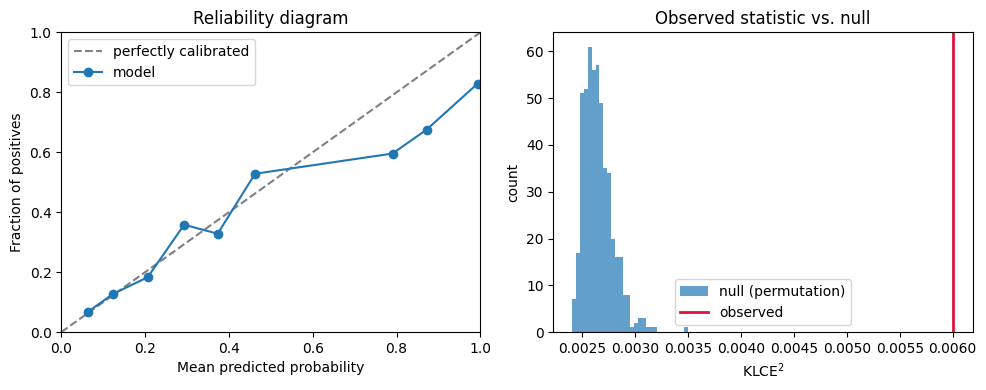

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

kcplots.reliability_diagram(y, f, n_bins=12, ax=ax1)

null = np.asarray(result.null_distribution)
ax2.hist(null, bins=30, alpha=0.7, label="null (permutation)")
ax2.axvline(float(result.statistic), color="crimson", lw=2, label="observed")
ax2.set_xlabel("KLCE$^2$")
ax2.set_ylabel("count")
ax2.set_title("Observed statistic vs. null")
ax2.legend()
fig.tight_layout()
plt.show()

## Sanity check: a calibrated model is *not* rejected

With `miscalibration=0`, the model matches the truth everywhere, so the test
should **not** reject.

In [6]:
Xc, yc, fc = kc.make_calibration_data(n=1000, miscalibration=0.0, seed=0)
pw, xw = kc.select_bandwidths(Xc, fc)
stat_c, p_c = kc.KLCE_test(Xc, yc, fc, pw, 500, key=0, x_kernel_width=xw)
print(f"calibrated model: p-value = {float(p_c):.3f} "
      f"({'reject' if float(p_c) < 0.05 else 'no evidence — as expected'})")

calibrated model: p-value = 0.503 (no evidence — as expected)


**Next:** see `02_recalibration.ipynb` to *fix* a miscalibrated model, and
`03_diagnostic_compas.ipynb` to localize *where* a real model is miscalibrated.